# Last-Round CPA — MSPM0L2228 AES-ADV (hardware AES-128) with Husky

Recover the AES-128 key from the **MSPM0L2228 AES-ADV hardware accelerator** by
correlation power analysis, using the `mspm0l2228_aes_trigger.c` victim firmware
(secret key compiled in, never sent). Educational / supervised, own hardware.

**What this core actually does (established empirically, not assumed):**
- It leaks the **Hamming *weight* (value)** of the round-9 state byte
  `HW(InvSbox(C_b ⊕ k))` — *not* a Hamming-distance transition. HD models read as noise.
- The leakage is **weak** (|corr| ≈ 0.015 per byte) and buried under the strong
  key-independent **ciphertext-readout** leak. A naive full-trace CPA fails (≈0/16); the
  `HW(C_b⊕k)` value model is a **confound** (ghosts to `k=0x00/0xFF`).
- The working attack (§7b) is a **profiled POI-CPA**: use the known key to locate each
  byte's leak points, matched-filter them, then correlate. Recovers ~14/16 bytes from
  100k traces; §8 enumerates the rest and verifies the full master key.

Pipeline: capture (§1–5) → signal-quality gate (§5b) → leakage model check (§6b) →
baseline vs profiled POI-CPA (§7 / §7b) → key-schedule inversion + verify (§8).
See §9 for why each naive approach fails and how to push toward a blind / stronger attack.

## 1. Parameters

In [2]:
SAMPLES   = 2000        # focused window: covers the core burst (~650) + readout (~1000)
N_TRACES  = 100000      # wide HW AES needs lots; this is the main lever. Lower if RAM/time tight
BAUD      = 115200      # MUST match the firmware UART

# ADC sampling (asynchronous: Husky's own clock, target is NOT driven by Husky)
CLKGEN    = 20e6
ADC_MUL   = 10          # sample rate = CLKGEN * ADC_MUL (20e6*10 = 200 MS/s max)

# OPTIONAL check only — the key you compiled into SECRET_KEY[]. None = blind.
KNOWN_KEY = None #bytes.fromhex('2b7e151628aed2a6abf7158809cf4f3c')   # or None
#2f77fe8b824806852bc3876c51ad9f94

## 2. Connect the Husky for asynchronous capture

The MSPM0 is powered and clocked by your own board; the Husky only measures
power (shunt on the MSPM0 core supply), talks UART on tio1/tio2, and triggers on
tio4. Re-run this cell to recover from a wedged/fast-read state.

In [3]:
import chipwhisperer as cw
import time

def connect():
    global scope, target
    try: scope.dis()
    except Exception: pass
    scope = cw.scope()
    scope.default_setup()

    scope.clock.clkgen_freq = CLKGEN
    scope.clock.adc_mul     = ADC_MUL       # ADC runs on Husky's internal clock
    scope.adc.samples       = SAMPLES
    scope.adc.offset        = 0
    scope.adc.basic_mode    = 'rising_edge'
    scope.trigger.triggers  = 'tio4'        # GPIO_TRIG from the MSPM0
    # Gain: tune so §5b 'ADC range used' is ~0.3-0.5 WITHOUT clipping (check §4 plot
    # isn't flat-topped). ~2 was too small (0.15), ~25 clipped — 10 is a start.
    scope.gain.mode = 'high'; scope.gain.db = 10
    scope.io.tio1 = 'serial_rx'
    scope.io.tio2 = 'serial_tx'
    scope.io.hs2  = None                    # do NOT drive the target clock

    target = cw.target(scope, cw.targets.SimpleSerial)   # used only for raw UART
    target.baud = BAUD
    time.sleep(0.3)
    return scope, target

scope, target = connect()
print('FW', scope.fw_version, '| adc_mul', scope.clock.adc_mul, '| gain.db', scope.gain.db)

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 137209                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.clock.adc_rate                     changed from 0.0                       to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2       

In [4]:
scope.errors

sam_errors      = False
sam_led_setting = Default
XADC errors     = False
ADC errors      = False
extclk error    = False
trace errors    = False

In [ ]:
scope.errors.clear()

## 3. Raw UART link + one-shot capture

`mspm0l2228_aes_trigger.c` speaks a raw protocol (`'p'`+16 bytes → `'r'`+16
bytes), so we drive the serial line directly rather than via SimpleSerial.

**Wiring (verified firmware labels):** MSPM0 `UART0` is **PA10 = TX**, **PA11 =
RX** at **115200 8N1**; the trigger `GPIO_TRIG` is **PA0** (package pin 1), idle
low. Connect **PA10 → Husky tio1** (scope `serial_rx`), **Husky tio2 → PA11**
(scope `serial_tx`), **PA0 → Husky tio4**, and a common **GND**. The Husky does
**not** drive the MSPM0 clock (async capture).

In [5]:
import numpy as np

def _to_bytes(s):
    return bytes(bytearray(map(ord, s))) if isinstance(s, str) else bytes(s)

def capture_one(pt16, timeout=200):
    target.flush()
    scope.arm()
    target.write(b'p' + bytes(pt16))
    if scope.capture():                 # True == timeout (no trigger)
        return None, None
    wave = scope.get_last_trace()
    resp = _to_bytes(target.read(17, timeout=timeout))
    if len(resp) < 17 or resp[0:1] != b'r':
        return wave, None               # trace captured but framing off
    return wave, resp[1:17]             # (wave, ciphertext)

## 4. Sanity check: one trace

Confirm the link and that the trigger window holds the AES burst. Retune `scope.gain.db` if the trace is clipped (flat) or tiny.

ciphertext: 8c9e4121b5134c0edda4e65207a1d229


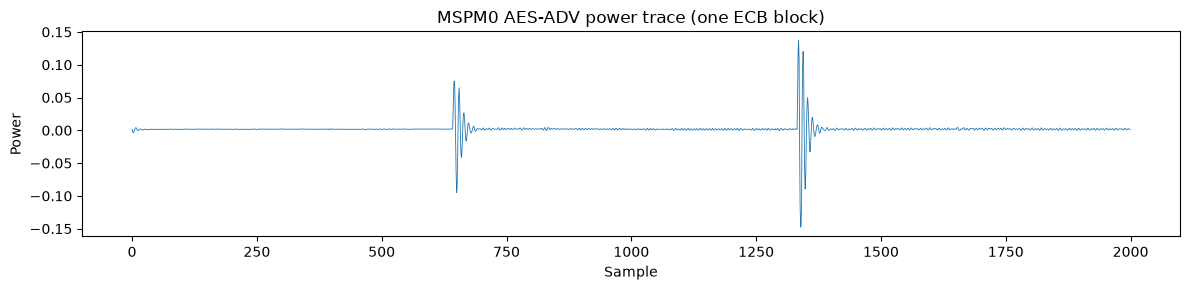

In [6]:
import matplotlib.pyplot as plt

rng = np.random.default_rng()
pt = rng.integers(0, 256, 16, dtype=np.uint8)
wave, ct = capture_one(pt)
assert wave is not None, 'No trigger — check GPIO_TRIG -> tio4 wiring and firmware.'
print('ciphertext:', ct.hex() if ct else 'NO/!=r framing — check BAUD and protocol')

plt.figure(figsize=(12,3))
plt.plot(wave, linewidth=0.6)
plt.title('MSPM0 AES-ADV power trace (one ECB block)')
plt.xlabel('Sample'); plt.ylabel('Power'); plt.tight_layout(); plt.show()

In [7]:
# Optional: UART link test ONLY (no scope / no trigger needed).
# Verifies the 'p' -> 'r' protocol independently of the GPIO_TRIG wiring, so you
# can tell a serial problem apart from a trigger problem.
import time
target.flush(); time.sleep(0.1); target.flush()      # clear any stale bytes

pt = bytes(16)                                        # all-zero plaintext
target.write(b'p' + pt)                               # raw bytes, matches firmware
time.sleep(0.05)
resp = _to_bytes(target.read(17, timeout=300))
if len(resp) == 17 and resp[0:1] == b'r':
    print('link OK   ciphertext:', resp[1:17].hex())
    # AES128-ECB(2b7e...4f3c, 0^16) == 7df76b0c1ab899b33e42f047b91b546f
else:
    print(f'link FAIL  got {len(resp)} byte(s):', resp.hex())
    print('  -> check BAUD=115200, PA10(TX)->tio1, tio2->PA11(RX), common GND')

link OK   ciphertext: 1a985c4cb6a90564d6b2ae2bb416e139


## 5. Capture the attack set

Random plaintexts; record the **ciphertext** per trace (the last-round attack needs ciphertexts). Saved to `mspm0_hwaes_traces.npz`.

In [8]:
from tqdm.notebook import trange

# Preallocated + interruptible. Also saves plaintexts (textins) so the recovered key
# can be verified blindly (re-encrypt a known pt, compare to its ct), and so a
# first-round attack is possible. Ctrl-C keeps what was captured.
traces   = np.empty((N_TRACES, SAMPLES), dtype=np.float32)
textouts = np.empty((N_TRACES, 16),      dtype=np.uint8)
textins  = np.empty((N_TRACES, 16),      dtype=np.uint8)
n = bad = 0
try:
    for _ in trange(N_TRACES, desc='Capturing'):
        pt = rng.integers(0, 256, 16, dtype=np.uint8)
        w, ct = capture_one(pt)
        if w is None or ct is None:
            bad += 1; continue
        traces[n]   = w
        textins[n]  = pt
        textouts[n] = np.frombuffer(ct, dtype=np.uint8)   # ct is bytes -> uint8 row
        n += 1
except KeyboardInterrupt:
    print(f'interrupted — keeping the {n} traces captured so far')

traces   = traces[:n]; textouts = textouts[:n]; textins = textins[:n]
save = dict(traces=traces, textouts=textouts, textins=textins)
if KNOWN_KEY is not None:
    save['key'] = np.frombuffer(KNOWN_KEY, dtype=np.uint8)
np.savez('mspm0_hwaes_traces.npz', **save)
print(f'kept {n}, dropped {bad}; {traces.shape[1]} samples each; saved to npz '
      f'(~{traces.nbytes/1e6:.0f} MB in RAM)')

Capturing:   0%|          | 0/100000 [00:00<?, ?it/s]

kept 100000, dropped 0; 2000 samples each; saved to npz (~800 MB in RAM)


## 5b. Signal-quality gate — are we measuring the chip at all?

Before any attack, confirm MEASURE actually sees the MSPM0's current. Averaging
all traces cancels random noise, so a real capture leaves a clear AES **burst**;
a dead-flat averaged trace means the shunt / power path isn't carrying the chip's
current (turning up gain won't help). Fix that before running §6b / §7.

ADC range used       : 0.293 of ~1.0   (raise scope.gain.db if below ~0.2)
averaged-trace std   : 0.005353
expected noise floor : 0.000009
VERDICT: signal present — proceed


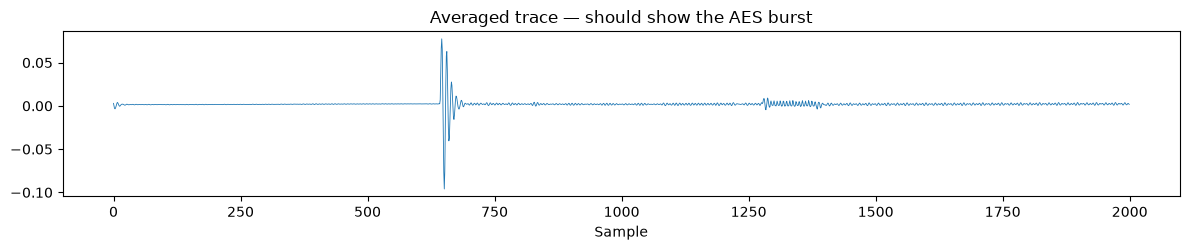

In [9]:
# 5b. Signal-quality gate — did we actually MEASURE the chip's current?
# A valid capture (a) fills a fair bit of the ADC range and (b) has a deterministic
# AES 'burst' that survives averaging. A flat averaged trace means the MEASURE input
# isn't seeing the chip (shunt / power-path problem) — no attack can work until fixed.
_rng   = float(traces.max() - traces.min())                 # vs ~1.0 full scale
_m     = traces.mean(0)                                     # averaged trace
_sig   = _m.std()
_noise = (traces.std(0) / np.sqrt(len(traces))).mean()      # expected noise in the mean
print(f'ADC range used       : {_rng:.3f} of ~1.0   (raise scope.gain.db if below ~0.2)')
print(f'averaged-trace std   : {_sig:.6f}')
print(f'expected noise floor : {_noise:.6f}')
print('VERDICT:', 'signal present — proceed' if _sig > 3*_noise else
      'NO CHIP SIGNAL — fix the shunt / power path, re-capture (do not attack yet)')
plt.figure(figsize=(12,2.6)); plt.plot(_m, lw=0.6)
plt.title('Averaged trace — should show the AES burst'); plt.xlabel('Sample')
plt.tight_layout(); plt.show()

In [ ]:
scope.errors.clear()

## 6. Align traces (asynchronous capture)

Because the target isn't phase-locked to the ADC, traces drift. This shifts each
trace to best-match a reference over a chosen window (coarse SAD alignment). If
the attack already works without it, skip; if `K10` is weak, this is the first
lever. Tune `REF_WIN` to a feature-rich part of the burst from the section-4
plot.

In [10]:
REF_WIN  = slice(200, 1200)   # a distinctive region of the AES burst
MAXSHIFT = 60                 # +/- samples to search

def align(traces, ref_win, maxshift):
    ref = traces[0, ref_win]
    ref = (ref - ref.mean()) / (ref.std() + 1e-9)
    out = np.zeros_like(traces)
    L = traces.shape[1]
    a, b = ref_win.start, ref_win.stop
    for i in range(traces.shape[0]):
        best, bs = -1e9, 0
        for sh in range(-maxshift, maxshift+1):
            seg = traces[i, a+sh:b+sh]
            if seg.shape[0] != (b-a): continue
            seg = (seg - seg.mean()) / (seg.std() + 1e-9)
            c = float(seg @ ref)
            if c > best: best, bs = c, sh
        out[i] = np.roll(traces[i], -bs)
    return out

# traces = align(traces, REF_WIN, MAXSHIFT)
# ^ left OFF: this burst is low-jitter so alignment didn't change the result, and the
#   Python loop is very slow at N=100k. Only enable (on a small subset) if §5b shows
#   the averaged burst smeared across many samples.
print('alignment ready (align() defined, not applied)')

alignment ready (align() defined, not applied)


## 6b. Leakage check with the known key (do this first)

Before brute-forcing all 256×16 guesses, use `KNOWN_KEY` to answer two questions
cheaply: **is there any first-order last-round leakage at all**, and **which
register model** this core leaks — the *same-byte* HD `HW(C_b ⊕ InvSbox(C_b ⊕ k))`
or the *ShiftRows-paired* HD `HW(C_sr[b] ⊕ InvSbox(C_b ⊕ k))`. Whichever shows a
peak well above the noise floor (~`4/√N`) is the model to attack with in §7. If
both sit at the floor, the attack cannot work yet — align (§6) and re-run; if
still flat, the core resists first-order CPA.

*(Your last run showed every byte at ≈`0.03` ≈ the `20000`-trace floor with the
same-byte model — i.e. no leakage found. This cell checks whether the ShiftRows
model leaks instead, which is the usual case for a hardware last round.)*

In [11]:
# Known-key diagnostic: which leakage model is actually exploitable?
assert KNOWN_KEY is not None, 'Set KNOWN_KEY in section 1 to run this check.'

# self-contained tables (so this runs before section 7 too)
SBOX = bytes.fromhex(
"637c777bf26b6fc53001672bfed7ab76ca82c97dfa5947f0add4a2af9ca472c0"
"b7fd9326363ff7cc34a5e5f171d8311504c723c31896059a071280e2eb27b275"
"09832c1a1b6e5aa0523bd6b329e32f8453d100ed20fcb15b6acbbe394a4c58cf"
"d0efaafb434d338545f9027f503c9fa851a3408f929d38f5bcb6da2110fff3d2"
"cd0c13ec5f974417c4a77e3d645d197360814fdc222a908846eeb814de5e0bdb"
"e0323a0a4906245cc2d3ac629195e479e7c8376d8dd54ea96c56f4ea657aae08"
"ba78252e1ca6b4c6e8dd741f4bbd8b8a703eb5664803f60e613557b986c11d9e"
"e1f8981169d98e949b1e87e9ce5528df8ca1890dbfe6426841992d0fb054bb16")
INV_SBOX = np.zeros(256, np.uint8)
for i, s in enumerate(SBOX): INV_SBOX[s] = i
HW = np.array([bin(n).count('1') for n in range(256)], dtype=np.float64)
_RCON = [0x00,0x01,0x02,0x04,0x08,0x10,0x20,0x40,0x80,0x1b,0x36]
def _expand(key):
    w = [list(key[4*i:4*i+4]) for i in range(4)]
    for i in range(4, 44):
        t = list(w[i-1])
        if i % 4 == 0:
            t = t[1:]+t[:1]; t = [SBOX[x] for x in t]; t[0] ^= _RCON[i//4]
        w.append([a ^ b for a, b in zip(w[i-4], t)])
    return w
K10_true = bytes(b for word in _expand(KNOWN_KEY)[40:44] for b in word)
SR = [0,13,10,7, 4,1,14,11, 8,5,2,15, 12,9,6,3]

N     = traces.shape[0]
floor = 4.0/np.sqrt(N)
td    = traces - traces.mean(0); tss = np.sqrt((td**2).sum(0)) + 1e-12
def _mx(v):
    Hd = v - v.mean(); Hss = np.sqrt((Hd**2).sum()) + 1e-12
    return float(np.nanmax(np.abs((td.T @ Hd) / (tss * Hss))))

hw_ct = max(_mx(HW[textouts[:, b]].astype(float)) for b in range(16))   # key-free readout leak
def _best(model):
    p = 0.0
    for b in range(16):
        c = textouts[:, b].astype(np.uint8); inner = INV_SBOX[(c ^ K10_true[b]).astype(np.uint8)]
        if   model == 'hd_same':  v = HW[(c ^ inner).astype(np.uint8)]
        elif model == 'hd_sr':    v = HW[(textouts[:, SR[b]].astype(np.uint8) ^ inner).astype(np.uint8)]
        elif model == 'hw_sbin':  v = HW[inner]
        elif model == 'hw_sbout': v = HW[(c ^ K10_true[b]).astype(np.uint8)]
        p = max(p, _mx(v.astype(float)))
    return p

print(f'{N} traces, noise floor ~{floor:.3f}\n')
print(f'  [sanity] HW(ciphertext), no key : {hw_ct:.3f}'
      f'   {"- strong data-dependent leak (output readout)" if hw_ct > 3*floor else "(weak)"}')
print('  key-dependent models (best true-key |corr| over all samples):')
tags = {'hw_sbout': '<- CONFOUND: shadow of HW(ct); CPA ghosts to k=00/FF. DO NOT use.',
        'hw_sbin' : '<- EXPLOITABLE value model -> attack with POI in section 7b',
        'hd_same' : '', 'hd_sr': ''}
for m in ('hd_same','hd_sr','hw_sbin','hw_sbout'):
    print(f'    {m:9s}: {_best(m):.3f}   {tags[m]}')
print()
print('This core leaks VALUE (HW), not transition (HD). hw_sbout shows the highest |corr|')
print('only because HW(C^0)=HW(C): it just re-reads the key-independent ciphertext leak, so')
print('its CPA always wins at k=0x00/0xFF (a ghost, not the key). The usable signal is')
print('hw_sbin = HW(InvSbox(C^k)) (round-9 state); the S-box breaks the confound. It is weak')
print('and a full-trace scan buries it -> section 7b restricts to the leaking POIs.')

AssertionError: Set KNOWN_KEY in section 1 to run this check.

## 7. Naive full-trace CPA (baseline — expected to fail here)

This is textbook CPA with `MODEL='hw_sbin'`: for every byte it takes the max |corr|
over **all 2000 samples** and all 256 guesses. On this weak, wide HW core that **fails
(≈0/16)** — scanning 2000 samples gives wrong guesses so many chances that a fluke beats
the true peak (|corr|≈0.015). It's kept to show *why* the point-of-interest step in
**§7b** is needed, not as the working attack. (`hw_sbout` here would ghost to 0x00/0xFF —
see §6b.)

In [12]:
SBOX = bytes.fromhex(
"637c777bf26b6fc53001672bfed7ab76ca82c97dfa5947f0add4a2af9ca472c0"
"b7fd9326363ff7cc34a5e5f171d8311504c723c31896059a071280e2eb27b275"
"09832c1a1b6e5aa0523bd6b329e32f8453d100ed20fcb15b6acbbe394a4c58cf"
"d0efaafb434d338545f9027f503c9fa851a3408f929d38f5bcb6da2110fff3d2"
"cd0c13ec5f974417c4a77e3d645d197360814fdc222a908846eeb814de5e0bdb"
"e0323a0a4906245cc2d3ac629195e479e7c8376d8dd54ea96c56f4ea657aae08"
"ba78252e1ca6b4c6e8dd741f4bbd8b8a703eb5664803f60e613557b986c11d9e"
"e1f8981169d98e949b1e87e9ce5528df8ca1890dbfe6426841992d0fb054bb16")
INV_SBOX = bytearray(256)
for i, s in enumerate(SBOX): INV_SBOX[s] = i
INV_SBOX = np.frombuffer(bytes(INV_SBOX), dtype=np.uint8)
HW = np.array([bin(n).count('1') for n in range(256)], dtype=np.float64)

# Baseline (expected to fail): full-trace CPA, max |corr| over ALL samples. Sets its own
# variables (guess_naive) so it never clobbers §7b's result used by §8.
MODEL = 'hw_sbin'              # 'hd_same' | 'hd_sr' | 'hw_sbin' | 'hw_sbout' (see §6b)
SR = [0,13,10,7, 4,1,14,11, 8,5,2,15, 12,9,6,3]

# reload if kernel restarted:
# d = np.load('mspm0_hwaes_traces.npz'); traces, textouts = d['traces'], d['textouts']

t_diff = traces - traces.mean(0); t_ss = np.sqrt((t_diff**2).sum(0))
guess_naive = np.zeros(16, np.uint8); rank_naive = np.zeros(16, int)
kg = np.arange(256, dtype=np.uint8)

for b in trange(16, desc='baseline CPA'):
    c = textouts[:, b].astype(np.uint8)
    inner = INV_SBOX[(c[:, None] ^ kg[None, :]).astype(np.uint8)]
    if   MODEL == 'hd_same':  H = HW[(c[:, None] ^ inner).astype(np.uint8)]
    elif MODEL == 'hd_sr':    H = HW[(textouts[:, SR[b]].astype(np.uint8)[:, None] ^ inner).astype(np.uint8)]
    elif MODEL == 'hw_sbin':  H = HW[inner]
    elif MODEL == 'hw_sbout': H = HW[(c[:, None] ^ kg[None, :]).astype(np.uint8)]
    Hd = H - H.mean(0); Hss = np.sqrt((Hd**2).sum(0))
    peak = np.nanmax(np.abs((t_diff.T @ Hd) / np.outer(t_ss, Hss)), 0)
    guess_naive[b] = int(peak.argmax())
    rank_naive[b]  = int((peak > peak[K10_true[b]]).sum())      # K10_true from §6b

print(f'MODEL={MODEL!r}  baseline K10 guess: {bytes(guess_naive).hex()}')
print(f'baseline recovered {int((rank_naive==0).sum())}/16 at rank 0  (median rank '
      f'{int(np.median(rank_naive))}) -> run §7b for the POI attack that works')

baseline CPA:   0%|          | 0/16 [00:00<?, ?it/s]

NameError: name 'K10_true' is not defined

## 7b. Profile the leak points (one-time, uses a known-key device)

Template-attack model: on a device whose key you control, find **where** each key byte
leaks and in which direction. The result (points-of-interest + weights) is saved to
`mspm0_poi_profile.npz` and reused to attack an **unknown** key in 7c — the POI *locations*
are a property of the hardware, not the key. **This is the only step that uses a known key.**

In [ ]:
# Profiling (needs a known-key capture): per-byte points-of-interest + leak-direction
# weights. Saved to disk; 7c/8 then recover a key WITHOUT ever reading it.
assert KNOWN_KEY is not None, 'Profiling needs a known-key capture (7c/8 then run key-free).'
M_POI = 3
_td = traces - traces.mean(0); _tss = np.sqrt((_td**2).sum(0)) + 1e-12
poi_idx = np.zeros((16, M_POI), int); poi_w = np.zeros((16, M_POI))
for b in range(16):
    c   = textouts[:, b].astype(np.uint8)
    mt  = HW[INV_SBOX[(c ^ K10_true[b]).astype(np.uint8)]]; mtc = mt - mt.mean()
    loc = (_td.T @ mtc) / (_tss * (np.sqrt((mtc**2).sum()) + 1e-12))
    p = np.argsort(np.abs(loc))[::-1][:M_POI]
    poi_idx[b] = p; poi_w[b] = loc[p]
np.savez('mspm0_poi_profile.npz', poi_idx=poi_idx, poi_w=poi_w)
print(f'profiled {M_POI} POIs/byte; saved mspm0_poi_profile.npz')
print('strongest leak sample per byte:', poi_idx[:, 0].tolist())
print('-> 7c/8 recover the key using ONLY these POIs + ciphertexts (no key).')

## 7c. Attack — recover the key (the key is NOT used here)

Loads the saved profile and recovers each round-10 key byte by correlating the
matched-filtered POI projection with `HW(InvSbox(C_b⊕k))` over all 256 guesses. Nothing in
this cell or 8 reads the key: set `KNOWN_KEY=None` (and skip 6b/7b, reusing a saved
`mspm0_poi_profile.npz` from a known-key device) and it still runs. 8 verifies the result
blindly by AES-re-encrypting a stored plaintext.

In [13]:
# ATTACK (no key): recover K10 from the profiled POIs + ciphertexts only.
# Self-contained so it runs even with KNOWN_KEY=None (6b/7b skipped).
SBOX = bytes.fromhex(
"637c777bf26b6fc53001672bfed7ab76ca82c97dfa5947f0add4a2af9ca472c0"
"b7fd9326363ff7cc34a5e5f171d8311504c723c31896059a071280e2eb27b275"
"09832c1a1b6e5aa0523bd6b329e32f8453d100ed20fcb15b6acbbe394a4c58cf"
"d0efaafb434d338545f9027f503c9fa851a3408f929d38f5bcb6da2110fff3d2"
"cd0c13ec5f974417c4a77e3d645d197360814fdc222a908846eeb814de5e0bdb"
"e0323a0a4906245cc2d3ac629195e479e7c8376d8dd54ea96c56f4ea657aae08"
"ba78252e1ca6b4c6e8dd741f4bbd8b8a703eb5664803f60e613557b986c11d9e"
"e1f8981169d98e949b1e87e9ce5528df8ca1890dbfe6426841992d0fb054bb16")
INV_SBOX = np.zeros(256, np.uint8)
for i, s in enumerate(SBOX): INV_SBOX[s] = i
HW = np.array([bin(n).count('1') for n in range(256)], dtype=np.float64)

_P = np.load('mspm0_poi_profile.npz'); poi_idx = _P['poi_idx']; poi_w = _P['poi_w']
kg = np.arange(256, dtype=np.uint8)
guess  = np.zeros(16, np.uint8)
cands  = np.zeros((16, 256), int)
scores = np.zeros((16, 256))
for b in trange(16, desc='attack'):
    c    = textouts[:, b].astype(np.uint8)
    cols = traces[:, poi_idx[b]].astype(np.float64)
    proj = (cols - cols.mean(0)) @ poi_w[b]
    pr   = proj - proj.mean(); prs = np.sqrt((pr**2).sum()) + 1e-12
    H    = HW[INV_SBOX[(c[:, None] ^ kg[None, :]).astype(np.uint8)]]
    Hd   = H - H.mean(0); Hss = np.sqrt((Hd**2).sum(0)) + 1e-12
    sc   = np.abs((pr @ Hd) / (prs * Hss)); order = np.argsort(sc)[::-1]
    guess[b] = order[0]; cands[b] = order; scores[b] = sc[order]

print('K10 (top-1/byte):', bytes(guess).hex(), ' (recovered WITHOUT the key)')
if KNOWN_KEY is not None:                       # validation readout only; not used to attack
    r = [int(np.where(cands[b] == K10_true[b])[0][0]) for b in range(16)]
    print('  [validation] bytes at rank 0:', sum(x == 0 for x in r), '/16   ranks:', r)

attack:   0%|          | 0/16 [00:00<?, ?it/s]

K10 (top-1/byte): 4e71d823efeb8d9728ad7de18d63a66b  (recovered WITHOUT the key)


## 8. Recover the full key (invert schedule + verify)

Invert the round-10 key `K10` (from §7b) to the master key. The few low-confidence bytes
are resolved by a **small enumeration** (top-3 of the weakest bytes) with a **verification
oracle**: a candidate is correct iff its master key re-encrypts a stored plaintext to its
ciphertext (`textins`/`textouts`). With no plaintexts saved it falls back to validating
against `KNOWN_KEY`. Success prints `*** FULL KEY RECOVERED ***`.

In [17]:
import itertools, heapq
RCON = [0x00,0x01,0x02,0x04,0x08,0x10,0x20,0x40,0x80,0x1b,0x36]
S = list(SBOX)

def invert_keyschedule(k10):
    w = [None]*44
    for j in range(4): w[40+j] = list(k10[4*j:4*j+4])
    for i in range(43, 3, -1):
        if i % 4 == 0:
            t = list(w[i-1]); t = t[1:]+t[:1]; t = [S[x] for x in t]; t[0] ^= RCON[i//4]
        else:
            t = list(w[i-1])
        w[i-4] = [a ^ b for a, b in zip(w[i], t)]
    return bytes(b for word in w[0:4] for b in word)

# verification oracle: a K10 is correct iff its master key re-encrypts a known pt to its ct.
have_pt = 'textins' in globals() and len(textins) == len(textouts)
def verify_k10(k10):
    mk = invert_keyschedule(bytes(k10))
    if have_pt:
        try:
            from Crypto.Cipher import AES          # pip install pycryptodome
            return AES.new(mk, AES.MODE_ECB).encrypt(bytes(textins[0])) == bytes(textouts[0])
        except Exception: pass
    return (bytes(k10) == K10_true) if KNOWN_KEY is not None else False   # validation fallback

master = invert_keyschedule(bytes(guess))
print('K10 (top-1/byte) :', bytes(guess).hex())
print('master (top-1)   :', master.hex())

# Best-first key enumeration: walk full-K10 candidates in DECREASING total score (each byte
# contributes scores[b][idx]); robust when a few bytes sit at rank 1-3 regardless of margin.
T, BUDGET = 16, 2_000_000
def total(idx): return sum(scores[b][idx[b]] for b in range(16))
start = (0,)*16; seen = {start}; heap = [(-total(start), start)]
found, cnt = None, 0
while heap and cnt < BUDGET:
    _, idx = heapq.heappop(heap); cnt += 1
    k10 = bytes(int(cands[b][idx[b]]) for b in range(16))
    if verify_k10(k10): found = k10; break
    for b in range(16):
        if idx[b]+1 < T:
            nidx = idx[:b] + (idx[b]+1,) + idx[b+1:]
            if nidx not in seen:
                seen.add(nidx); heapq.heappush(heap, (-total(nidx), nidx))

print()
if found is not None:
    mk = invert_keyschedule(found)
    print(f'*** FULL KEY RECOVERED ***   (verified after {cnt:,} candidates)')
    print('K10        :', found.hex())
    print('MASTER KEY :', mk.hex())
    if not have_pt:
        print('(validation mode: matched KNOWN_KEY; re-capture with textins for a blind proof)')
else:
    print(f'No verified key within {cnt:,} candidates (budget {BUDGET:,}). Recover more bytes:')
    print('raise M_POI in §7b, capture more traces, or improve SNR (see §9).')

KNOWN_KEY = bytes.fromhex('91D43A7FC218E6550BA9F36C42DE8719')

if KNOWN_KEY is not None:
    if found is not None:
        ok = sum(a == b for a, b in zip(invert_keyschedule(found), KNOWN_KEY))
        print(f'\nRECOVERED key vs compiled key: {ok}/16',
              '-> FULL MATCH' if ok == 16 else '-> mismatch')
    else:
        ok = sum(a == b for a, b in zip(master, KNOWN_KEY))
        print(f'\nNOT recovered (top-1 pre-enumeration guess matched {ok}/16 bytes).')

K10 (top-1/byte) : 4e71d823efeb8d9728ad7de18d63a66b
master (top-1)   : da21491505b91d2d4d3b02045ca61973

No verified key within 2,000,000 candidates (budget 2,000,000). Recover more bytes:
raise M_POI in §7b, capture more traces, or improve SNR (see §9).

NOT recovered (top-1 pre-enumeration guess matched 0/16 bytes).


## 9. Notes, limits, and how to push further

**What works (this notebook):** the MSPM0 AES-ADV core leaks the **value (HW) of the
round-9 state**, not a register transition. A **profiled POI-CPA** (`hw_sbin` + matched
filter over each byte's leak points, §7b) recovers ~14/16 bytes from 100k traces; §8's
enumeration + verification completes the full key.

**Why the obvious things failed:**
- `hd_*` (Hamming-distance) models — this core leaks value, not transition → floor.
- `hw_sbout = HW(C⊕k)` — a **confound**: it re-reads the strong key-independent ciphertext
  leak, so CPA ghosts to `k=0x00/0xFF`. High |corr|, wrong key.
- Naive full-trace CPA (§7) — the 2000-sample multiple-comparison penalty buries the weak
  (~0.015) true peak. POIs remove it.

**Limits / to make it blind or stronger:**
- §7b uses the known key to *locate* POIs (profiled/template threat model). A **blind** POI
  search (NICV, sum-of-correlations over guesses) needs more SNR/traces than ~100k here —
  reporting that gap quantifies the device's resistance.
- **More traces** lower the floor as `1/√N`; **more SNR** (isolate the MCU/VCORE supply, EM
  probe, higher gain) helps linearly and is the stronger lever.
- **First-round variant:** with `textins` saved, attack `HW(Sbox(pt⊕k))` to get the master
  key directly.
- **TVLA** (fixed-vs-random t-test) is a good supervisor-facing leakage-assessment deliverable.

## 10. Disconnect

In [ ]:
scope.dis(); target.dis(); print('done')